In [ ]:
#3.1. Загрузка и первичное знакомство с данными

import pandas as pd

df = pd.read_csv('Tetuan City power consumption.csv')

print("Первые 5 строк данных:")
print(df.head())

print("\nИнформация о данных:")
print(df.info())

print(f"\nРазмерность: {df.shape[0]} строк, {df.shape[1]} столбцов")

df['DateTime'] = pd.to_datetime(df['DateTime'])
df.set_index('DateTime', inplace=True)

print(f"\nНачало временного ряда: {df.index.min()}")
print(f"Конец временного ряда: {df.index.max()}")
print(f"Количество наблюдений: {len(df)}")

Первые 5 строк данных:
        DateTime  Temperature  Humidity  Wind Speed  general diffuse flows  \
0  1/1/2017 0:00        6.559      73.8       0.083                  0.051   
1  1/1/2017 0:10        6.414      74.5       0.083                  0.070   
2  1/1/2017 0:20        6.313      74.5       0.080                  0.062   
3  1/1/2017 0:30        6.121      75.0       0.083                  0.091   
4  1/1/2017 0:40        5.921      75.7       0.081                  0.048   

   diffuse flows  Zone 1 Power Consumption  Zone 2  Power Consumption  \
0          0.119               34055.69620                16128.87538   
1          0.085               29814.68354                19375.07599   
2          0.100               29128.10127                19006.68693   
3          0.096               28228.86076                18361.09422   
4          0.085               27335.69620                17872.34043   

   Zone 3  Power Consumption  
0                20240.96386  
1      

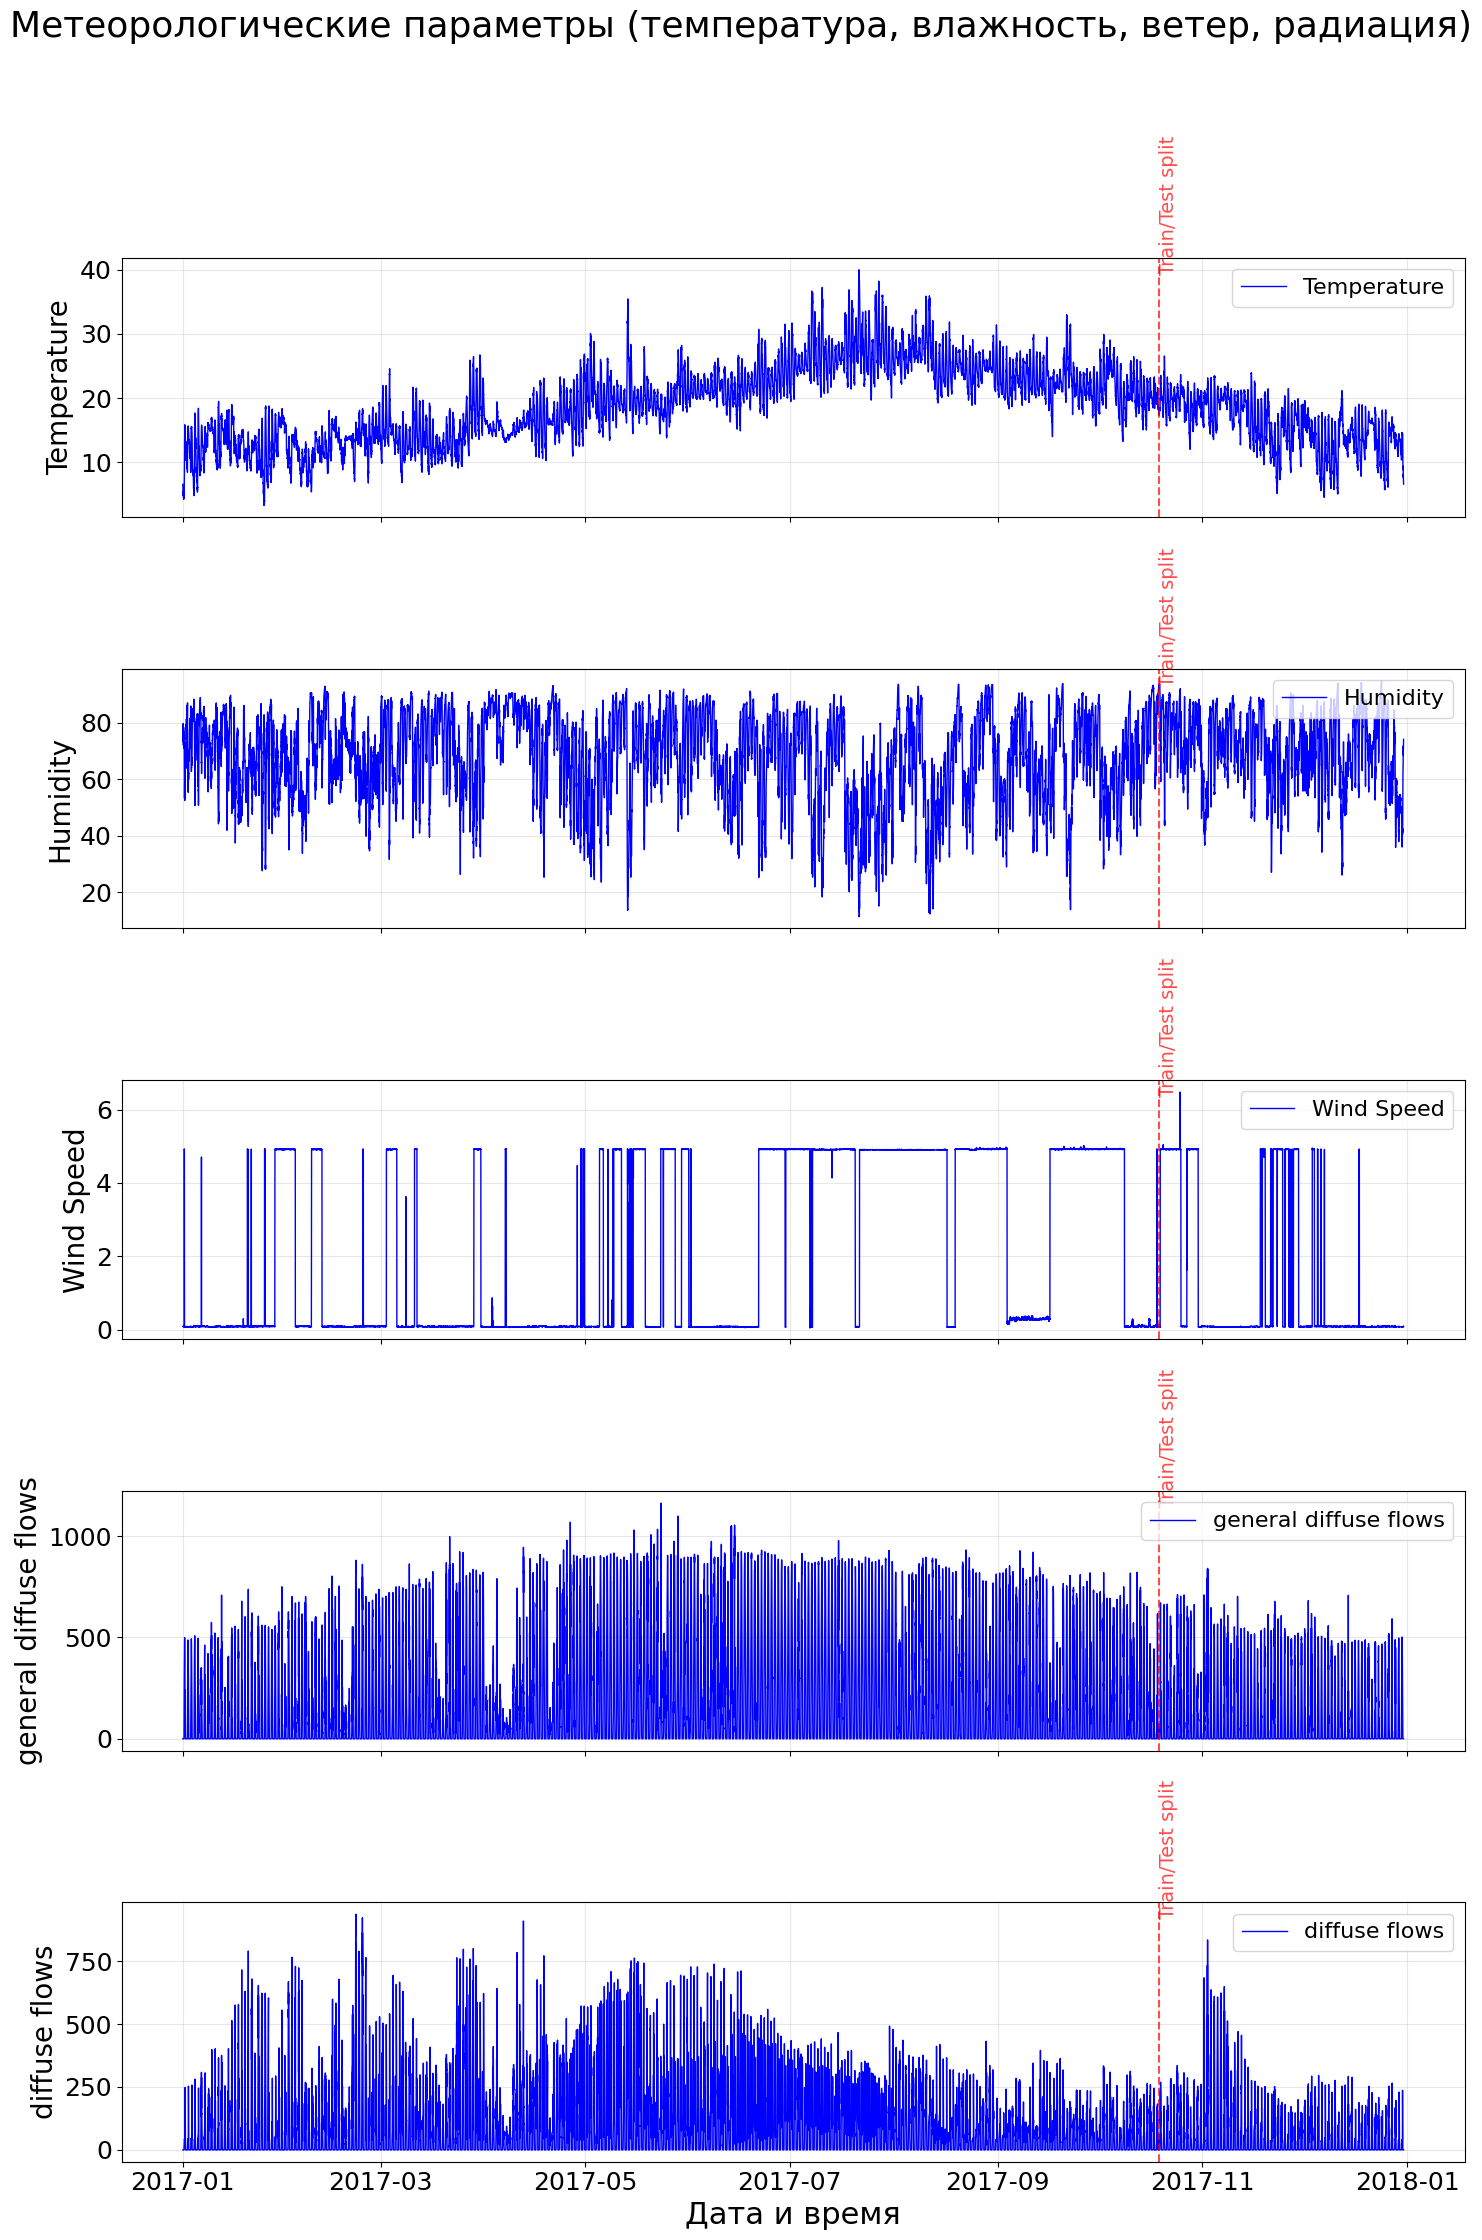

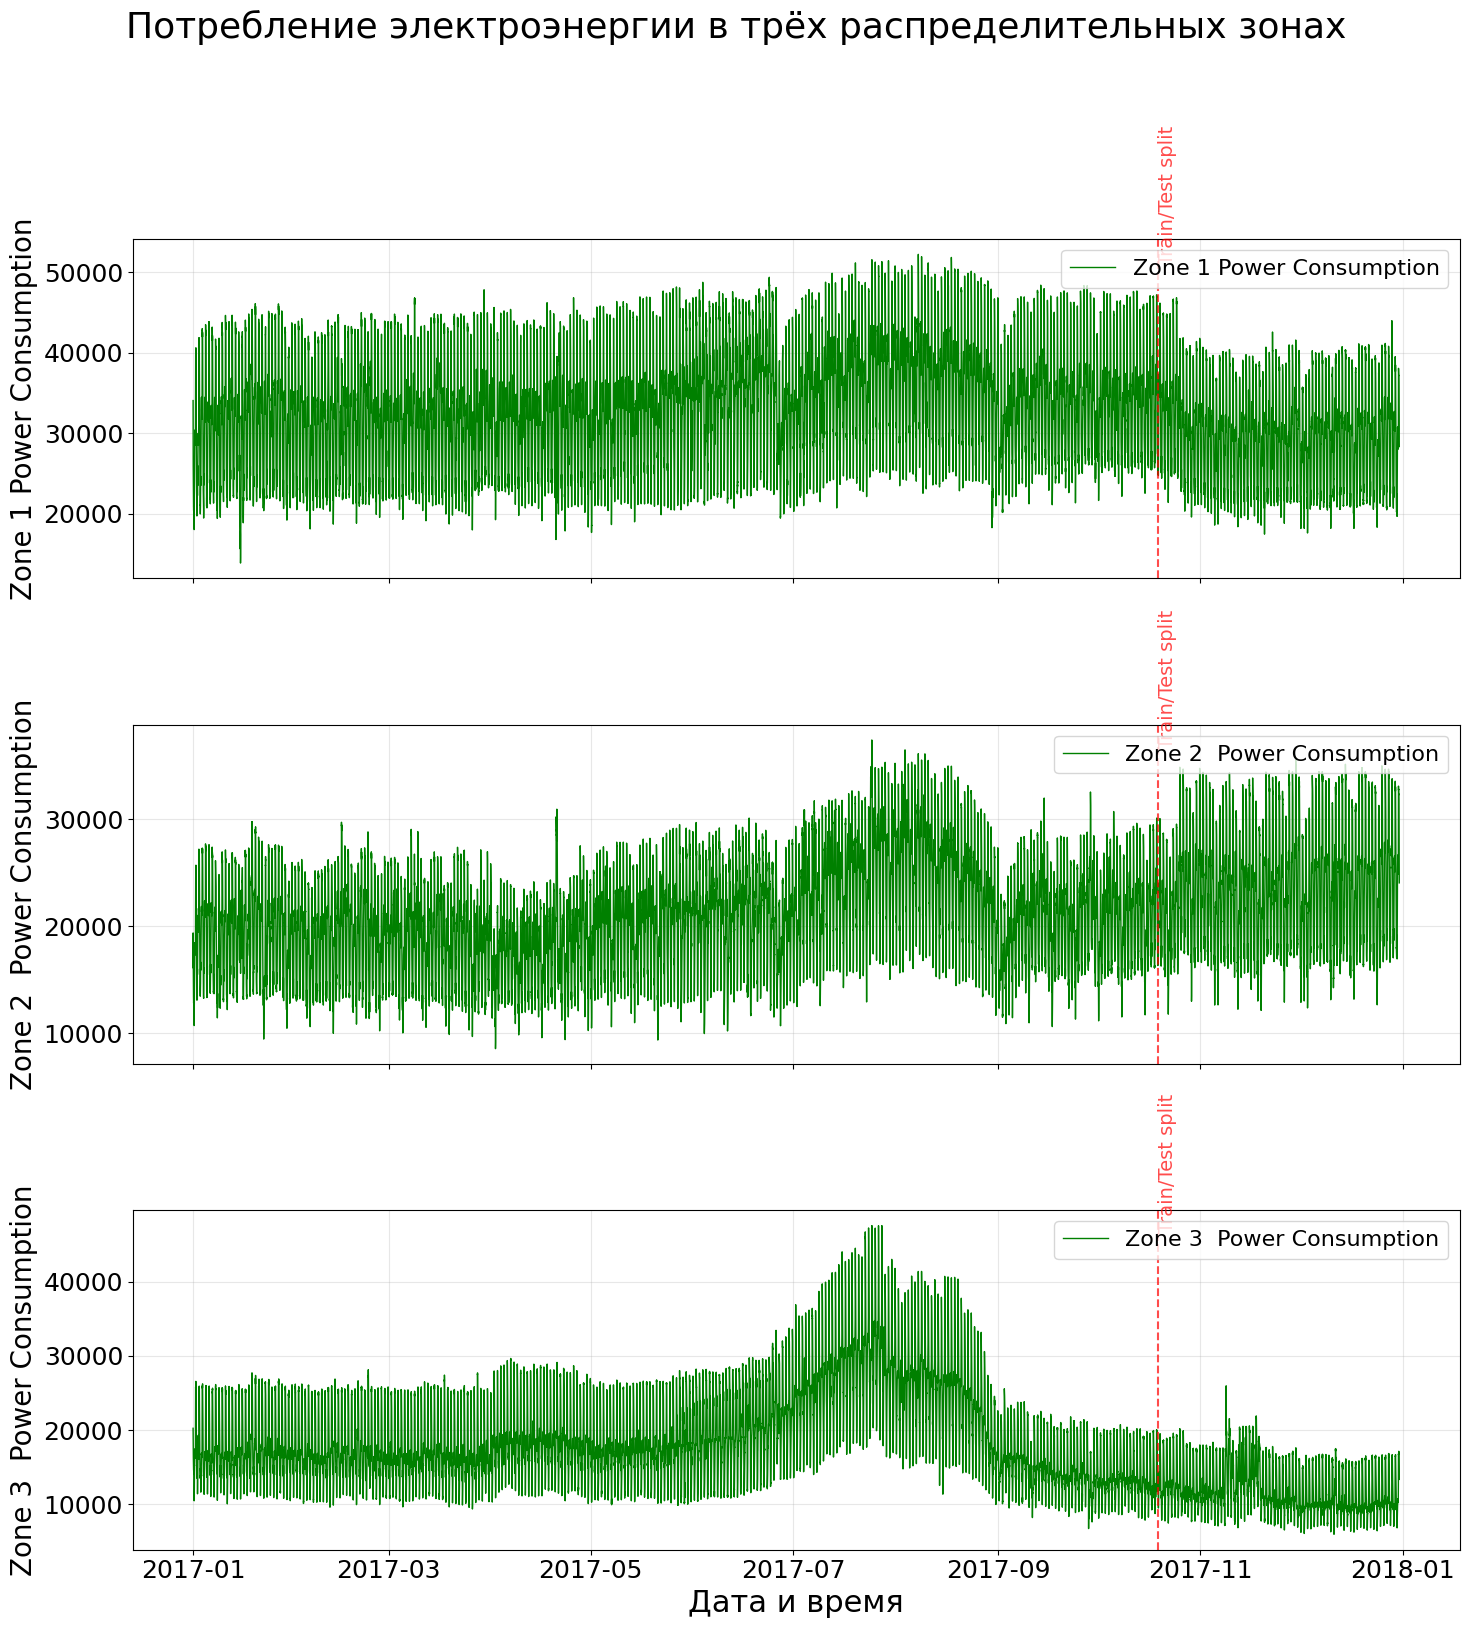

In [ ]:
#3.2.
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({'font.size': 16})

df = pd.read_csv('Tetuan City power consumption.csv')
df['DateTime'] = pd.to_datetime(df['DateTime'])
df.set_index('DateTime', inplace=True)


train_size = int(len(df) * 0.8)
split_date = df.index[train_size]

channels_meteo = [
    'Temperature', 'Humidity', 'Wind Speed',
    'general diffuse flows', 'diffuse flows'
]

fig1, axes1 = plt.subplots(5, 1, figsize=(15, 22), sharex=True)
plt.subplots_adjust(hspace=0.4)

for i, col in enumerate(channels_meteo):
    axes1[i].plot(df.index, df[col], linewidth=1.0, color='blue', label=col)
    axes1[i].set_ylabel(col, fontsize=20)
    axes1[i].grid(True, alpha=0.3)
    axes1[i].tick_params(axis='both', labelsize=18)
    axes1[i].legend(loc='upper right', fontsize=16)
    axes1[i].axvline(x=split_date, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    axes1[i].text(split_date, axes1[i].get_ylim()[1]*0.95, 'Train/Test split',
                  rotation=90, fontsize=14, color='red', alpha=0.7)

axes1[-1].set_xlabel('Дата и время', fontsize=22)
plt.suptitle('Метеорологические параметры (температура, влажность, ветер, радиация)',
             fontsize=26, y=1.02)
plt.tight_layout()
plt.show()

channels_power = [
    'Zone 1 Power Consumption',
    'Zone 2  Power Consumption',
    'Zone 3  Power Consumption'
]

fig2, axes2 = plt.subplots(3, 1, figsize=(15, 16), sharex=True)
plt.subplots_adjust(hspace=0.35)

for i, col in enumerate(channels_power):
    axes2[i].plot(df.index, df[col], linewidth=1.0, color='green', label=col)
    axes2[i].set_ylabel(col, fontsize=20)
    axes2[i].grid(True, alpha=0.3)
    axes2[i].tick_params(axis='both', labelsize=18)
    axes2[i].legend(loc='upper right', fontsize=16)
    axes2[i].axvline(x=split_date, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
    axes2[i].text(split_date, axes2[i].get_ylim()[1]*0.95, 'Train/Test split',
                  rotation=90, fontsize=14, color='red', alpha=0.7)

axes2[-1].set_xlabel('Дата и время', fontsize=22)
plt.suptitle('Потребление электроэнергии в трёх распределительных зонах',
             fontsize=26, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
#3.3.
import pandas as pd
import numpy as np

df = pd.read_csv('Tetuan City power consumption.csv')
df['DateTime'] = pd.to_datetime(df['DateTime'])
df.set_index('DateTime', inplace=True)

stats = df.describe(percentiles=[0.25, 0.5, 0.75]).T
stats['Q1'] = stats['25%']
stats['Q2'] = stats['50%']
stats['Q3'] = stats['75%']
stats = stats[['count', 'mean', 'std', 'min', 'Q1', 'Q2', 'Q3', 'max']]
stats['skew'] = df.skew()

print("Статистические характеристики каналов:")
print(stats.round(4))

freq = pd.infer_freq(df.index)
print(f"\nЧастота дискретизации: {freq}")

time_diffs = df.index.to_series().diff().mode()[0]
print(f"Наиболее частый интервал: {time_diffs}")

Статистические характеристики каналов:
                             count        mean        std         min  \
Temperature                52416.0     18.8100     5.8155      3.2470   
Humidity                   52416.0     68.2595    15.5512     11.3400   
Wind Speed                 52416.0      1.9595     2.3489      0.0500   
general diffuse flows      52416.0    182.6966   264.4010      0.0040   
diffuse flows              52416.0     75.0280   124.2109      0.0110   
Zone 1 Power Consumption   52416.0  32344.9706  7130.5626  13895.6962   
Zone 2  Power Consumption  52416.0  21042.5091  5201.4659   8560.0815   
Zone 3  Power Consumption  52416.0  17835.4062  6622.1651   5935.1741   

                                   Q1          Q2          Q3         max  \
Temperature                   14.4100     18.7800     22.8900     40.0100   
Humidity                      58.3100     69.8600     81.4000     94.8000   
Wind Speed                     0.0780      0.0860      4.9150      6.483

Доля пропущенных значений (%):
Temperature                  0.0
Humidity                     0.0
Wind Speed                   0.0
general diffuse flows        0.0
diffuse flows                0.0
Zone 1 Power Consumption     0.0
Zone 2  Power Consumption    0.0
Zone 3  Power Consumption    0.0
dtype: float64

Количество выбросов по правилу 3σ:
Temperature                    89 (0.17%)
Humidity                       209 (0.40%)
Wind Speed                     0 (0.00%)
general diffuse flows          23 (0.04%)
diffuse flows                  1361 (2.60%)
Zone 1 Power Consumption       0 (0.00%)
Zone 2  Power Consumption      1 (0.00%)
Zone 3  Power Consumption      653 (1.25%)


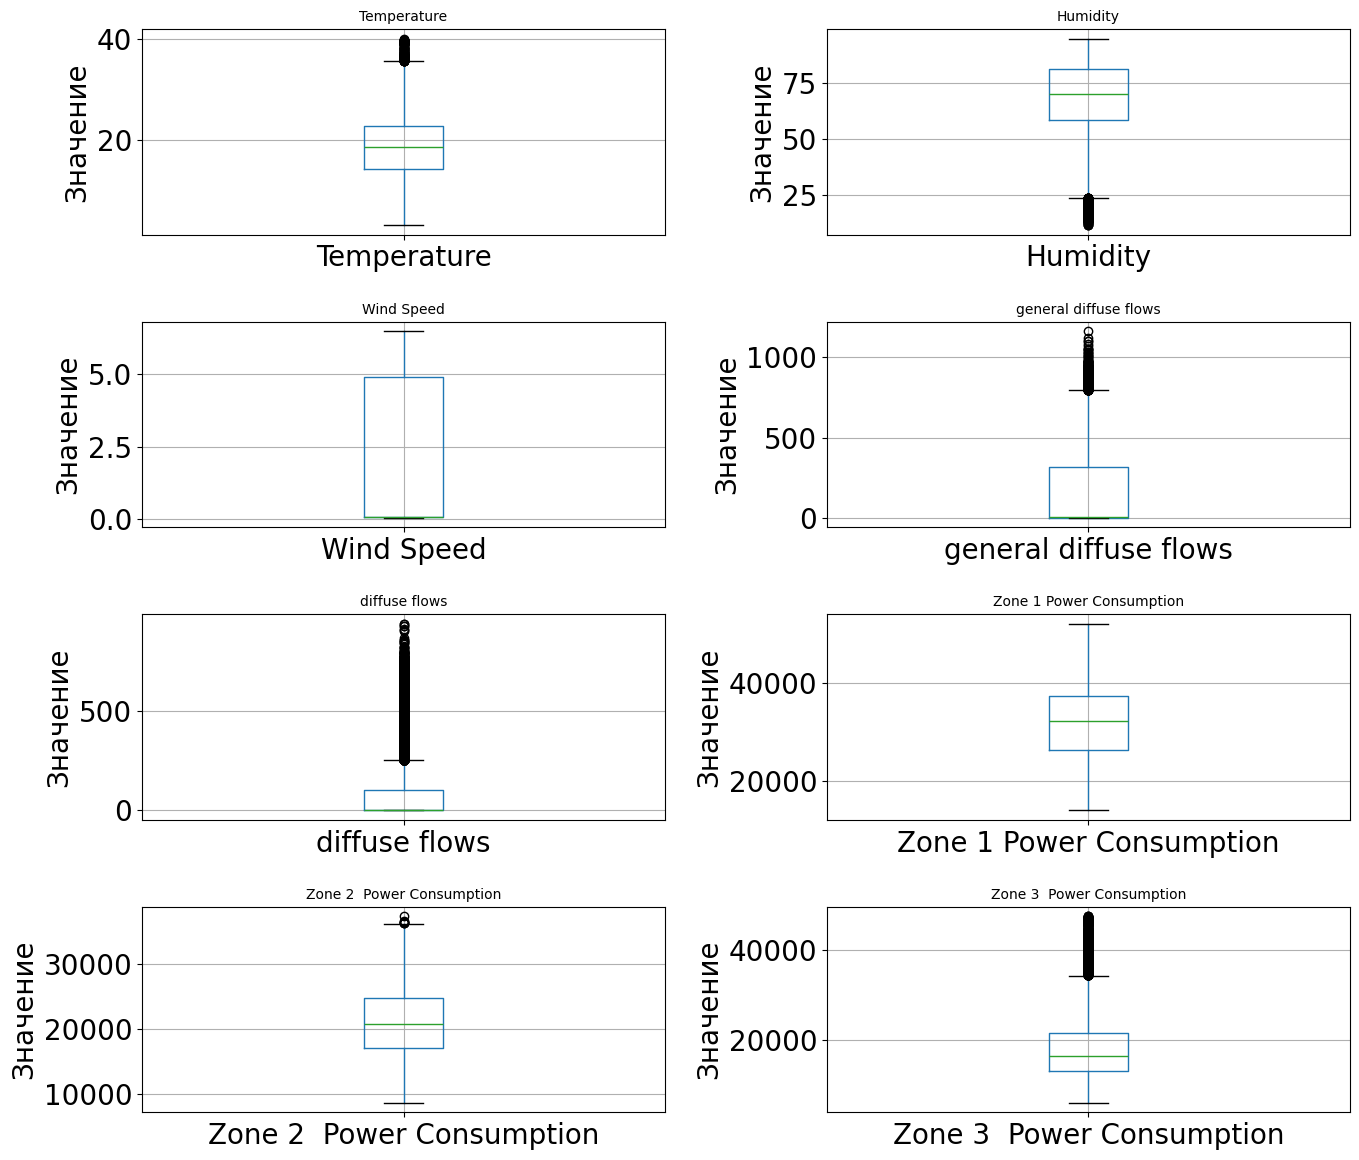

In [ ]:
#3.4.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv('Tetuan City power consumption.csv')
df['DateTime'] = pd.to_datetime(df['DateTime'])
df.set_index('DateTime', inplace=True)

missing_ratio = df.isnull().sum() / len(df) * 100
print("Доля пропущенных значений (%):")
print(missing_ratio)
print()

outliers_count = {}
for col in df.columns:
    mean = df[col].mean()
    std = df[col].std()
    lower = mean - 3*std
    upper = mean + 3*std
    outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outliers_count[col] = outliers

print("Количество выбросов по правилу 3σ:")
for col, cnt in outliers_count.items():
    print(f"{col:30} {cnt} ({cnt/len(df)*100:.2f}%)")

fig, axes = plt.subplots(4, 2, figsize=(14, 12))
axes = axes.flatten()
for i, col in enumerate(df.columns):
    df.boxplot(column=col, ax=axes[i])
    axes[i].set_title(col, fontsize=10)
    axes[i].set_ylabel('Значение')
plt.tight_layout()
plt.show()

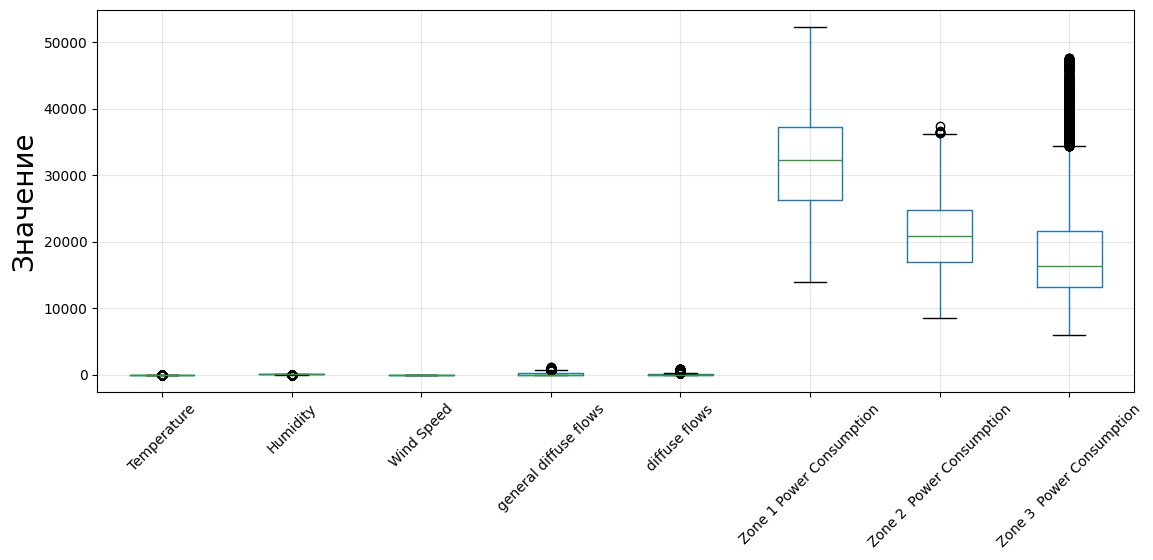

In [ ]:
#3.5.
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('Tetuan City power consumption.csv')
df['DateTime'] = pd.to_datetime(df['DateTime'])
df.set_index('DateTime', inplace=True)

plt.figure(figsize=(12, 6))
df.boxplot(rot=45, fontsize=10)
plt.ylabel('Значение')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Матрица корреляции Пирсона:
                           Temperature  Humidity  Wind Speed  \
Temperature                      1.000    -0.460       0.477   
Humidity                        -0.460     1.000      -0.136   
Wind Speed                       0.477    -0.136       1.000   
general diffuse flows            0.460    -0.468       0.134   
diffuse flows                    0.197    -0.257      -0.001   
Zone 1 Power Consumption         0.440    -0.287       0.167   
Zone 2  Power Consumption        0.382    -0.295       0.146   
Zone 3  Power Consumption        0.490    -0.233       0.279   

                           general diffuse flows  diffuse flows  \
Temperature                                0.460          0.197   
Humidity                                  -0.468         -0.257   
Wind Speed                                 0.134         -0.001   
general diffuse flows                      1.000          0.565   
diffuse flows                              0.565          1.

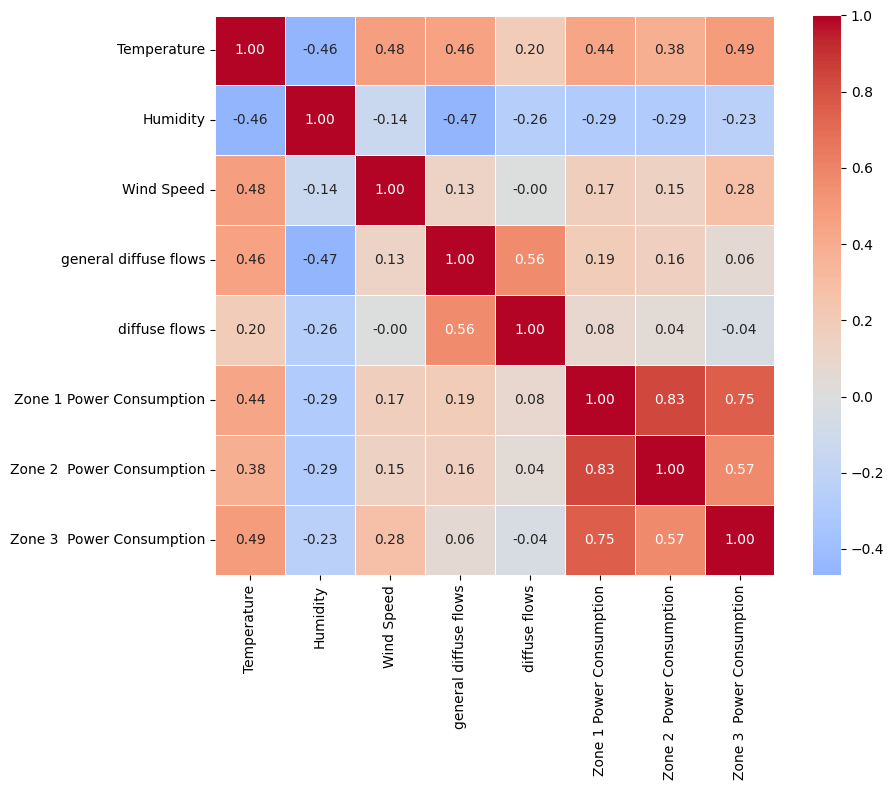

In [ ]:
#3.6.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Tetuan City power consumption.csv')
df['DateTime'] = pd.to_datetime(df['DateTime'])
df.set_index('DateTime', inplace=True)

corr_matrix = df.corr(method='pearson')
print("Матрица корреляции Пирсона:")
print(corr_matrix.round(3))

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0,
            fmt='.2f', square=True, linewidths=0.5)
plt.tight_layout()
plt.show()

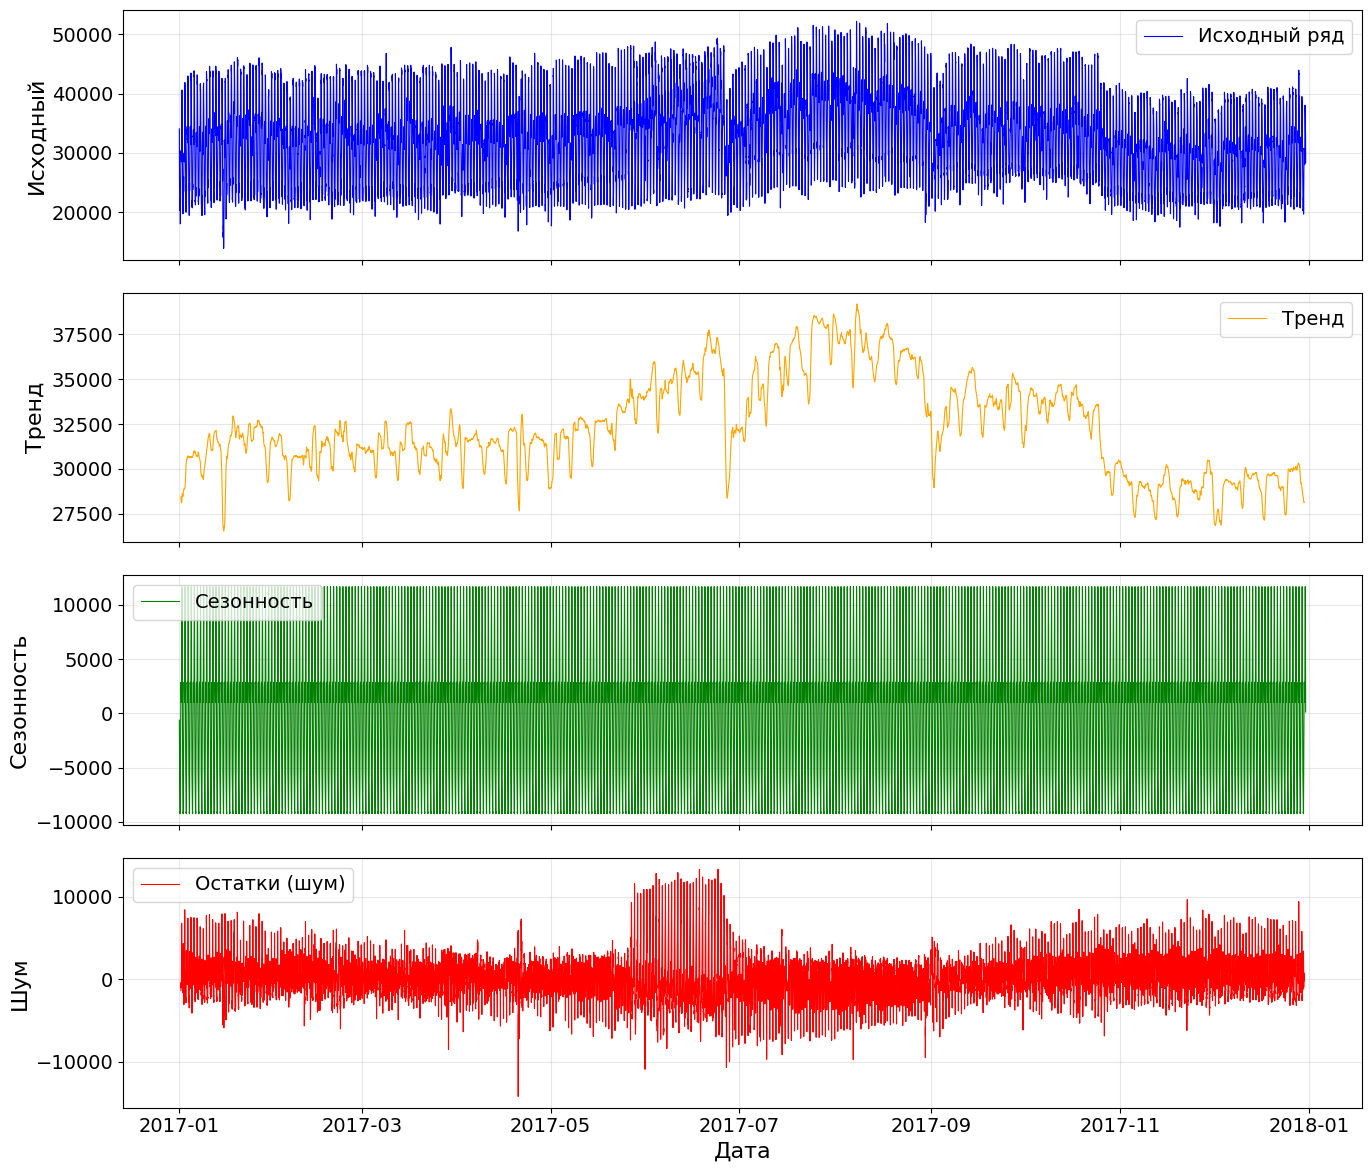

SNR = 9.43 дБ


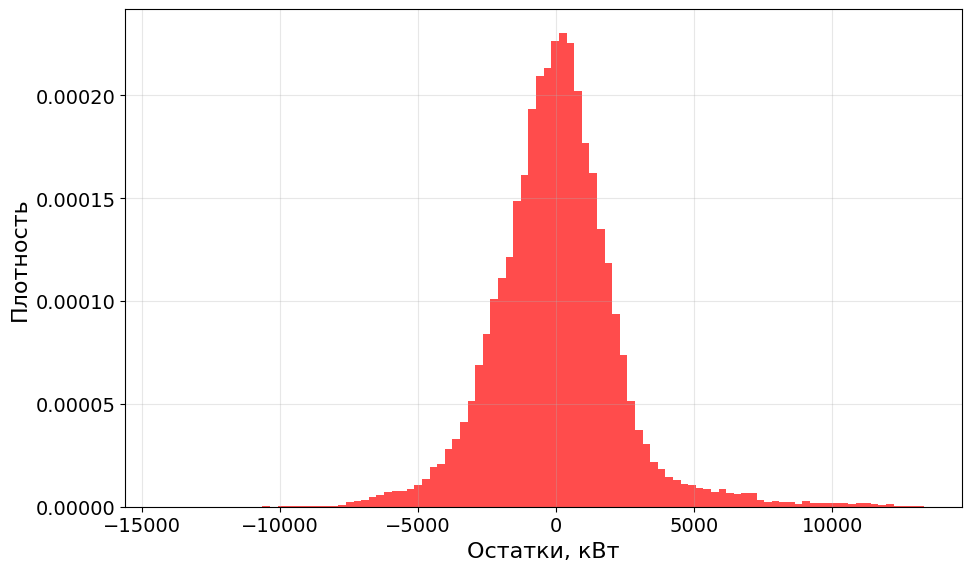

In [17]:
#3.7
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

plt.rcParams.update({
    'font.size': 16,
    'axes.titlesize': 18,
    'axes.labelsize': 16,
    'xtick.labelsize': 14,
    'ytick.labelsize': 14,
    'legend.fontsize': 14,
    'figure.titlesize': 20
})

df = pd.read_csv('Tetuan City power consumption.csv')
df['DateTime'] = pd.to_datetime(df['DateTime'])
df.set_index('DateTime', inplace=True)

series = df['Zone 1 Power Consumption']

decomp = seasonal_decompose(series, model='additive', period=144)

fig, (ax1, ax2, ax3, ax4) = plt.subplots(4, 1, figsize=(14, 12), sharex=True)

ax1.plot(series, label='Исходный ряд', color='blue', linewidth=0.8)
ax1.set_ylabel('Исходный')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(decomp.trend, label='Тренд', color='orange', linewidth=0.8)
ax2.set_ylabel('Тренд')
ax2.legend()
ax2.grid(True, alpha=0.3)

ax3.plot(decomp.seasonal, label='Сезонность', color='green', linewidth=0.8)
ax3.set_ylabel('Сезонность')
ax3.legend()
ax3.grid(True, alpha=0.3)

ax4.plot(decomp.resid, label='Остатки (шум)', color='red', linewidth=0.8)
ax4.set_ylabel('Шум')
ax4.legend()
ax4.grid(True, alpha=0.3)
ax4.set_xlabel('Дата')

plt.tight_layout()
plt.show()

signal = decomp.trend + decomp.seasonal
signal_var = np.nanvar(signal)
noise_var = np.nanvar(decomp.resid)
SNR = 10 * np.log10(signal_var / noise_var)
print(f'SNR = {SNR:.2f} дБ')

plt.figure(figsize=(10, 6))
plt.hist(decomp.resid.dropna(), bins=100, density=True, alpha=0.7, color='red')
plt.xlabel('Остатки, кВт', fontsize=16)
plt.ylabel('Плотность', fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [19]:
import pandas as pd
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose

# Загрузка данных (предполагается, что df уже загружен и DateTime в индексе)
# df = pd.read_csv('Tetuan City power consumption.csv')
# df['DateTime'] = pd.to_datetime(df['DateTime'])
# df.set_index('DateTime', inplace=True)

zone1 = df['Zone 1 Power Consumption']

# Декомпозиция (период 144)
decomp = seasonal_decompose(zone1, model='additive', period=144)

# --- 1. Тренд: средние значения в январе и декабре ---
trend = decomp.trend.dropna()
# Январь: первые 30 дней * 144 отсчёта = 4320
jan_trend = trend[:4320].mean()
# Декабрь: последние 30 дней
dec_trend = trend[-4320:].mean()
trend_change = dec_trend - jan_trend
print(f"Тренд в январе: {jan_trend:.2f} кВт")
print(f"Тренд в декабре: {dec_trend:.2f} кВт")
print(f"Изменение тренда за год: {trend_change:.2f} кВт (снижение)")

# --- 2. Амплитуда сезонности (максимум - минимум в пределах суток) ---
seasonal = decomp.seasonal
# Берём один полный период (144 отсчёта) – например, первые сутки
one_day = seasonal[:144]
amplitude = one_day.max() - one_day.min()
print(f"\nАмплитуда суточной сезонности: {amplitude:.2f} кВт")
print(f"Диапазон: от {one_day.min():.2f} до {one_day.max():.2f} кВт")

# --- 3. Шум: среднее значение остатков, дисперсия, подтверждение нулевого среднего ---
residuals = decomp.resid.dropna()
mean_noise = residuals.mean()
std_noise = residuals.std()
print(f"\nСреднее значение остатков (шума): {mean_noise:.4f} кВт (≈0)")
print(f"Стандартное отклонение остатков: {std_noise:.2f} кВт")

# --- 4. Дополнительно: дисперсии для SNR (как уже считали) ---
signal = decomp.trend + decomp.seasonal
valid = ~(signal.isna() | decomp.resid.isna())
signal_clean = signal[valid]
noise_clean = decomp.resid[valid]
signal_var = np.var(signal_clean)
noise_var = np.var(noise_clean)
SNR = 10 * np.log10(signal_var / noise_var)
print(f"\nSNR = {SNR:.2f} дБ")

Тренд в январе: 31061.40 кВт
Тренд в декабре: 29053.59 кВт
Изменение тренда за год: -2007.81 кВт (снижение)

Амплитуда суточной сезонности: 20933.46 кВт
Диапазон: от -9254.83 до 11678.63 кВт

Среднее значение остатков (шума): 0.6422 кВт (≈0)
Стандартное отклонение остатков: 2275.26 кВт

SNR = 9.43 дБ
